In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

## Import Data / Label Encoding

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/temp.csv")
df['dateTime']= pd.to_datetime(df['dateTime'])
df.drop("0",axis=1,inplace=True)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['dateTime'] = le.fit_transform(df['dateTime'])
df.head()

,dateTime,current1,current2,current3,power1,power2,power3,voltage1,voltage2,voltage3
0,0,3.53,3.33,3.62,436.1,446.0,501.0,241.1,240.4,243.1
1,1,NaN,3.32,3.59,NaN,444.6,497.3,NaN,240.2,242.8
2,2,NaN,3.32,3.57,NaN,445.9,490.4,NaN,239.9,241.8
3,3,NaN,3.30,3.58,NaN,444.7,495.9,NaN,239.4,241.9
4,4,3.47,3.33,3.57,437.1,448.0,491.2,240.2,239.7,241.6


## KNN Imputer

In [ ]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)
df_imputed['dateTime'] = df_imputed['dateTime'].round().astype(int)
df_imputed['dateTime'] = le.inverse_transform(df_imputed['dateTime'])
df_imputed.head()

,dateTime,current1,current2,current3,power1,power2,power3,voltage1,voltage2,voltage3
0,2025-03-17 13:28:36,3.530,3.33,3.62,436.10,446.0,501.0,241.1,240.4,243.1
1,2025-03-17 13:33:38,3.476,3.32,3.59,434.04,444.6,497.3,239.6,240.2,242.8
2,2025-03-17 13:38:41,3.476,3.32,3.57,434.72,445.9,490.4,239.6,239.9,241.8
3,2025-03-17 13:43:42,3.476,3.30,3.58,434.04,444.7,495.9,239.6,239.4,241.9
4,2025-03-17 13:48:44,3.470,3.33,3.57,437.10,448.0,491.2,240.2,239.7,241.6


In [ ]:
df_knn = df_imputed.groupby(pd.Grouper(key='dateTime', axis=0, freq='h',dropna=False)).mean(numeric_only =True)
df_knn['activePowerT']  = df_knn['power1']+df_knn['power2']+df_knn['power3']
df_knn.head(15)

,current1,current2,current3,power1,power2,power3,voltage1,voltage2,voltage3,activePowerT
dateTime,,,,,,,,,,
2025-03-17 13:00:00,3.480571,3.311429,3.577143,434.300000,445.071429,494.414286,239.842857,239.571429,241.957143,1373.785714
2025-03-17 14:00:00,3.482000,3.283333,3.553333,434.698333,439.916667,494.158333,239.510000,238.850000,241.241667,1368.773333
2025-03-17 15:00:00,3.497667,3.290833,3.566667,435.456667,438.483333,495.100000,240.165000,239.483333,241.983333,1369.040000
2025-03-17 16:00:00,3.497667,3.304167,3.579167,434.870000,440.858333,494.400000,240.520000,239.891667,242.275000,1370.128333
2025-03-17 17:00:00,3.527000,3.337500,3.587500,437.675000,441.750000,492.350000,241.150000,241.000000,243.275000,1371.775000
2025-03-17 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd

def process_dataframe(df):
    """
    Iterates over each column in the DataFrame and processes it.
    Example operation: Fills NaN values with the column mean if it's numeric.

    Parameters:
    df (pd.DataFrame): Input DataFrame.

    Returns:
    pd.DataFrame: Processed DataFrame with NaN values replaced (if applicable).
    """
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:  # Check if the column is numeric
            df[col] = df[col].fillna(df[col].mean())  # Replace NaNs with column mean


    return df

df_mean = process_dataframe(df)
df_mean = pd.DataFrame(imputer.fit_transform(df_mean), columns=df.columns, index=df.index)
df_mean['dateTime'] = df_mean['dateTime'].round().astype(int)
df_mean['dateTime'] = le.inverse_transform(df_mean['dateTime'])
df_mean.head()

,dateTime,current1,current2,current3,power1,power2,power3,voltage1,voltage2,voltage3
0,2025-03-17 13:28:36,3.530000,3.33,3.62,436.100000,446.0,501.0,241.100000,240.4,243.1
1,2025-03-17 13:33:38,3.546522,3.32,3.59,439.517733,444.6,497.3,241.582716,240.2,242.8
2,2025-03-17 13:38:41,3.546522,3.32,3.57,439.517733,445.9,490.4,241.582716,239.9,241.8
3,2025-03-17 13:43:42,3.546522,3.30,3.58,439.517733,444.7,495.9,241.582716,239.4,241.9
4,2025-03-17 13:48:44,3.470000,3.33,3.57,437.100000,448.0,491.2,240.200000,239.7,241.6


In [ ]:
df_mean = df_mean.groupby(pd.Grouper(key='dateTime', axis=0, freq='h',dropna=False)).mean(numeric_only =True)

df_mean['activePowerT']  = df_mean['power1']+df_mean['power2']+df_mean['power3']
df_mean.head(15)

,current1,current2,current3,power1,power2,power3,voltage1,voltage2,voltage3,activePowerT
dateTime,,,,,,,,,,
2025-03-17 13:00:00,3.520870,3.311429,3.577143,436.550457,445.071429,494.414286,240.975838,239.571429,241.957143,1376.036171
2025-03-17 14:00:00,3.529058,3.283333,3.553333,438.045155,439.916667,494.158333,241.110597,238.850000,241.549040,1372.120155
2025-03-17 15:00:00,3.517717,3.290833,3.566667,436.471100,438.483333,495.100000,241.014918,239.483333,241.983333,1370.054433
2025-03-17 16:00:00,3.522138,3.304167,3.579167,437.077011,440.858333,494.400000,241.073251,239.891667,242.275000,1372.335344
2025-03-17 17:00:00,3.535761,3.337500,3.587500,437.629433,441.750000,492.350000,241.562037,241.000000,243.275000,1371.729433
2025-03-17 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-17 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Create a full hourly range from 12 AM to 11 PM

full_hours = pd.date_range("2025-03-17 00:00:00", "2025-04-17 23:00:00", freq='h')

# Reindex to fill missing timestamps with NaN
knn_full = df_knn.reindex(full_hours)
knn_full.fillna(0,inplace=True)
knn_full.head(15)

,current1,current2,current3,power1,power2,power3,voltage1,voltage2,voltage3,activePowerT
2025-03-17 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 02:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 03:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 04:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 05:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 06:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 07:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 08:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 09:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
# Reindex to fill missing timestamps with NaN
mean_full = df_mean.reindex(full_hours)
mean_full.fillna(0,inplace=True)
mean_full.head(15)

,current1,current2,current3,power1,power2,power3,voltage1,voltage2,voltage3,activePowerT
2025-03-17 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 02:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 03:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 04:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 05:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 06:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 07:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 08:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-17 09:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
mean_full.tail()

,current1,current2,current3,power1,power2,power3,voltage1,voltage2,voltage3,activePowerT
2025-04-17 19:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-04-17 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-04-17 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-04-17 22:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-04-17 23:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Datasets/data.xlsx")
df['dateTime'] = pd.to_datetime(df['dateTime'])
df.set_index('dateTime',inplace=True)
df = df.reindex(full_hours)
df.fillna(0,inplace=True)

df.head(20)

,voltageA,voltageB,voltageC,currentA,currentB,currentC,activepowerA,activepowerB,activepowerC,activePowerT
2025-03-17 00:00:00,0.416056,0.415611,0.415861,0.657222,0.557778,0.487222,0.000000,0.000000,0.000000,0.000000
2025-03-17 01:00:00,0.410917,0.410667,0.411250,0.660833,0.554167,0.495278,0.000000,0.000000,0.000000,0.000000
2025-03-17 02:00:00,0.413556,0.413306,0.412583,0.666944,0.555278,0.497778,0.000000,0.000000,0.000000,0.000000
2025-03-17 03:00:00,0.413722,0.413556,0.413639,0.661944,0.554167,0.495833,0.000000,0.000000,0.000000,0.000000
2025-03-17 04:00:00,0.409833,0.409778,0.410500,0.662778,0.553333,0.504444,0.000000,0.000000,0.000000,0.000000
2025-03-17 05:00:00,0.416806,0.416611,0.416806,0.660278,0.556944,0.501389,0.000000,0.000000,0.000000,0.000000
2025-03-17 06:00:00,0.427972,0.427500,0.427972,0.655833,0.561944,0.494167,0.000000,0.000000,0.000000,0.000000
2025-03-17 07:00:00,0.418972,0.418694,0.418861,0.650833,0.556389,0.504722,0.000000,0.000000,0.000000,0.000000
2025-03-17 08:00:00,0.409500,0.408667,0.408333,0.652500,0.559167,0.509444,0.000000,0.000000,0.000000,0.000000
2025-03-17 09:00:00,186.218472,185.487000,187.465889,3.058333,2.770278,3.032778,324.000000,335.416667,374.722222,1033.055556


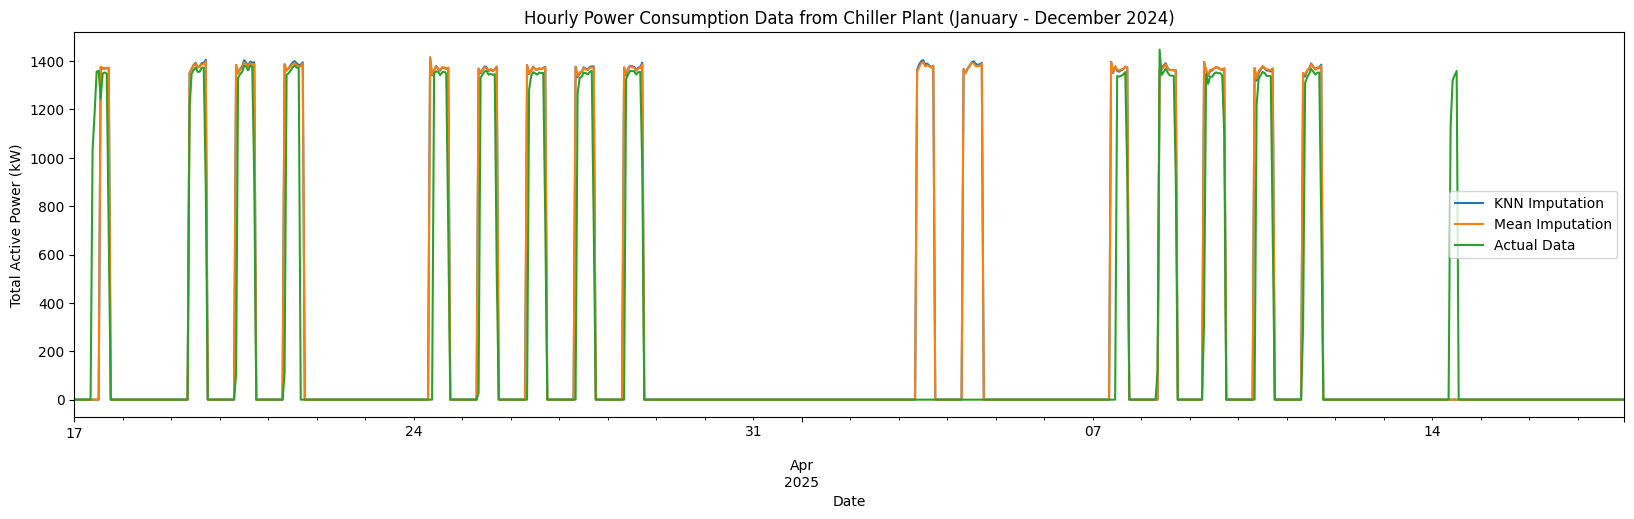

In [ ]:
fig, ax = plt.subplots()
knn_full.plot( y=['activePowerT'], ax=ax,figsize=(20,5),title ='Hourly Power Consumption Data from Chiller Plant (January - December 2024)',xlabel='Date',ylabel='Total Active Power (kW)')
mean_full.plot( y=['activePowerT'], ax=ax,figsize=(20,5),title ='Hourly Power Consumption Data from Chiller Plant (January - December 2024)',xlabel='Date',ylabel='Total Active Power (kW)')
df.plot(y=['activePowerT'],ax=ax)
ax.legend(['KNN Imputation','Mean Imputation','Actual Data'])

In [ ]:
df.head()
# knn_full.loc["2025-03-24 08:00:00	"] = 0
# knn_full.loc["2025-03-24 09:00:00	"] = 0
# knn_full.loc["2025-03-26 08:00:00	"] = 0
# knn_full.loc["2025-03-27 08:00:00	"] = 0
# mean_full.loc["2025-03-24 08:00:00	"] = 0
# mean_full.loc["2025-03-24 09:00:00	"] = 0
# mean_full.loc["2025-03-26 08:00:00	"] = 0
# mean_full.loc["2025-03-27 08:00:00	"] = 0

,voltageA,voltageB,voltageC,currentA,currentB,currentC,activepowerA,activepowerB,activepowerC,activePowerT
2025-03-17 00:00:00,0.416056,0.415611,0.415861,0.657222,0.557778,0.487222,0.0,0.0,0.0,0.0
2025-03-17 01:00:00,0.410917,0.410667,0.411250,0.660833,0.554167,0.495278,0.0,0.0,0.0,0.0
2025-03-17 02:00:00,0.413556,0.413306,0.412583,0.666944,0.555278,0.497778,0.0,0.0,0.0,0.0
2025-03-17 03:00:00,0.413722,0.413556,0.413639,0.661944,0.554167,0.495833,0.0,0.0,0.0,0.0
2025-03-17 04:00:00,0.409833,0.409778,0.410500,0.662778,0.553333,0.504444,0.0,0.0,0.0,0.0


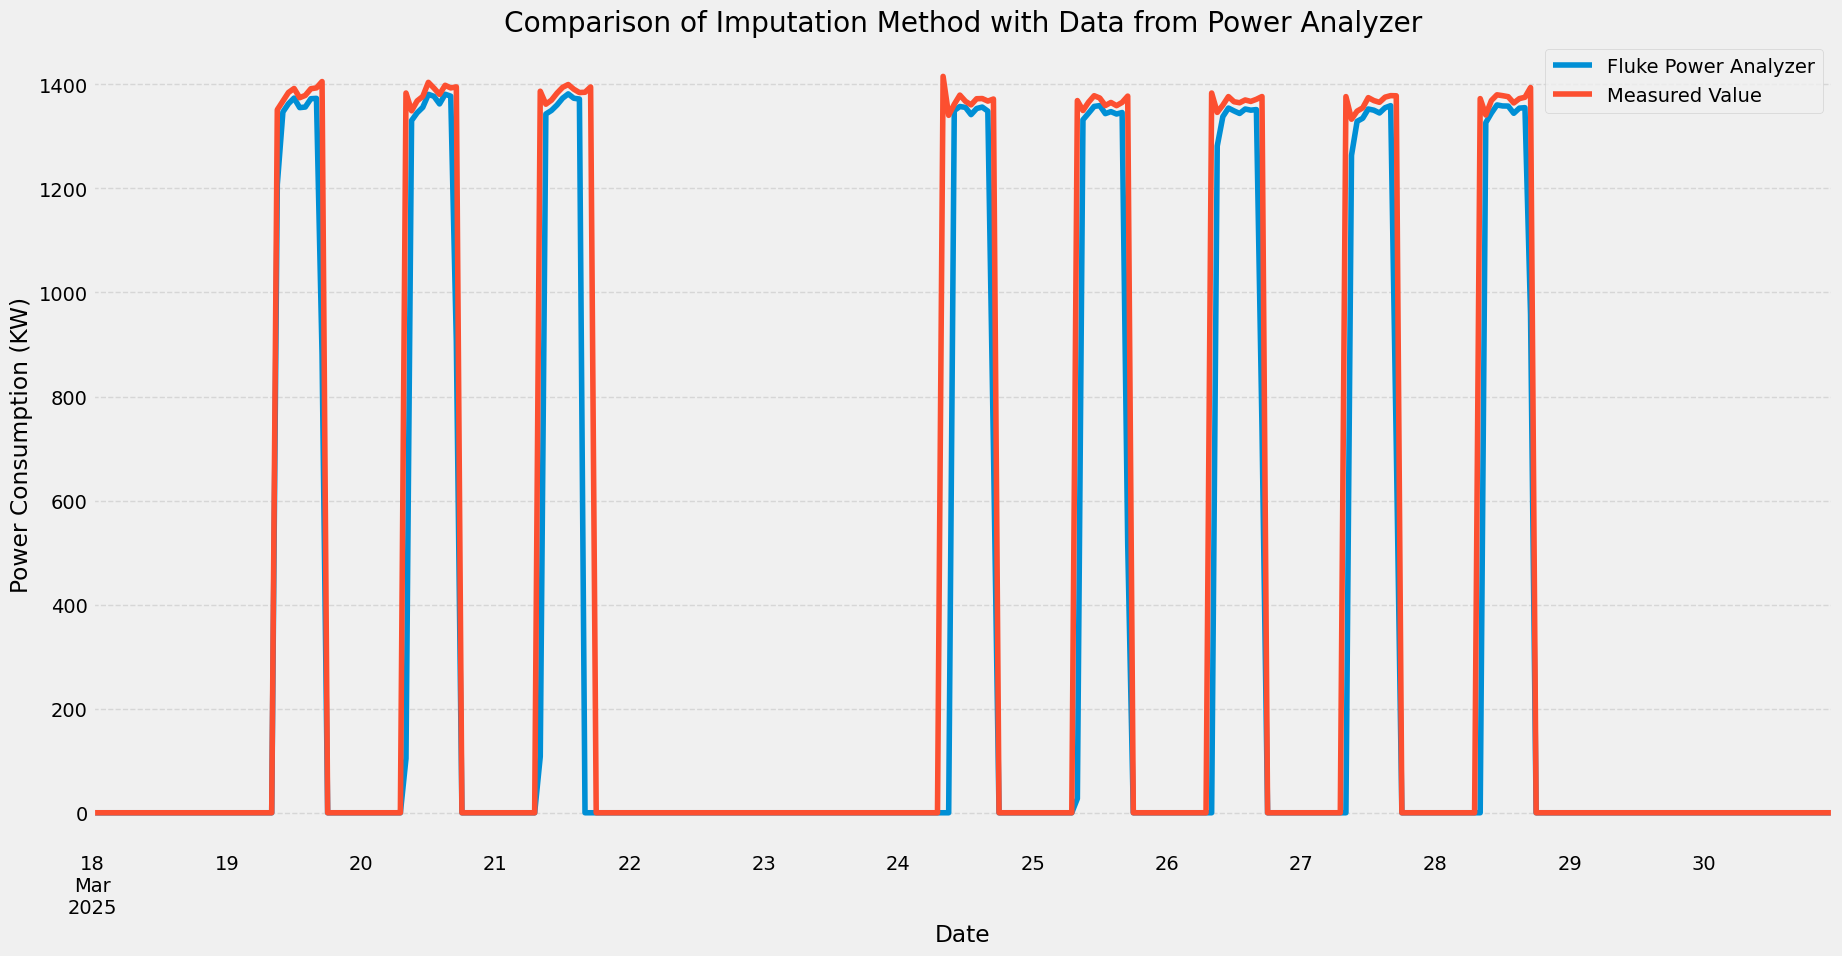

In [ ]:
ax = df.loc[(df.index >= '2025-03-18') & (df.index < '2025-03-31')].plot(y=['activePowerT'],title='Comparison of Imputation Method with Data from Power Analyzer',xlabel='Date',ylabel='Power Consumption (KW)',figsize=(20,10))
knn_full.loc[(df.index >= '2025-03-18') & (df.index < '2025-03-31')].plot(y=['activePowerT'],ax=ax)
ax.legend(['Fluke Power Analyzer','Measured Value'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig = ax.get_figure()
fig.savefig('/content/drive/MyDrive/Images/Final/Accuracy')

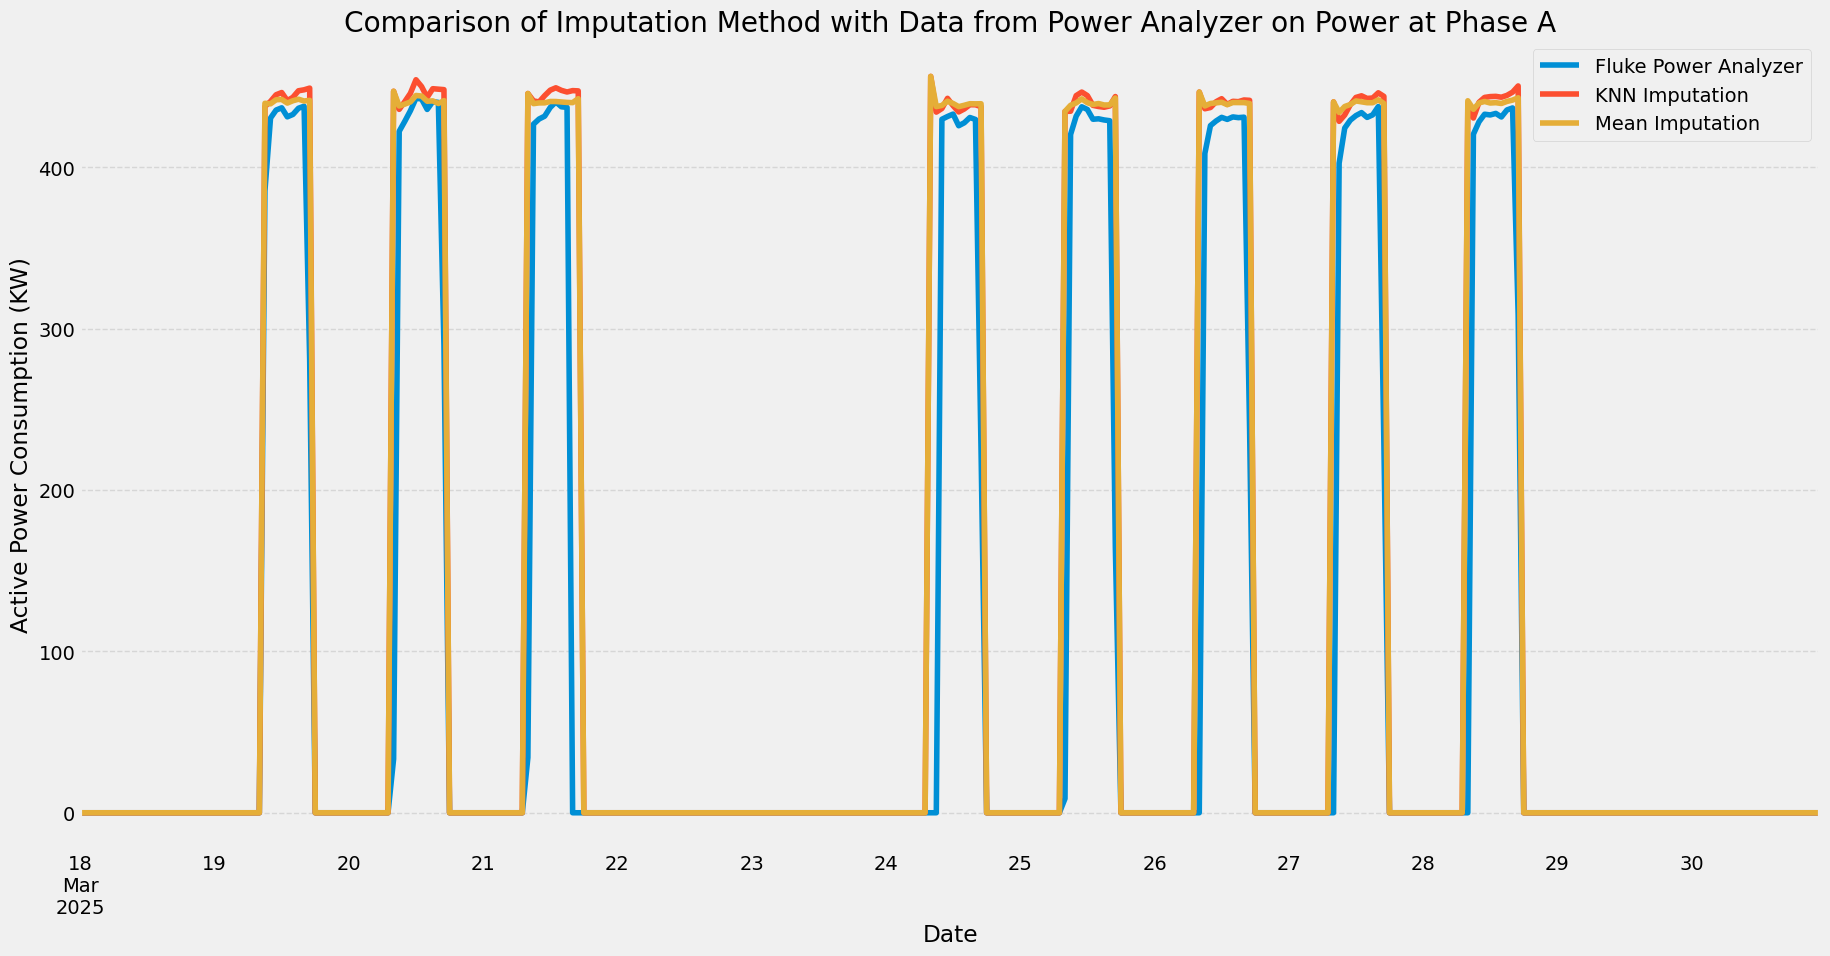

In [ ]:
ax = df.loc[(df.index >= '2025-03-18') & (df.index < '2025-03-31')].plot(y=['activepowerA'],title='Comparison of Imputation Method with Data from Power Analyzer on Power at Phase A',xlabel='Date',ylabel='Active Power Consumption (KW)',figsize=(20,10))
knn_full.loc[(df.index >= '2025-03-18') & (df.index < '2025-03-31')].plot(y=['power1'],ax=ax)
mean_full.loc[(df.index >= '2025-03-18') & (df.index < '2025-03-31')].plot(y=['power1'],ax=ax)
ax.legend(['Fluke Power Analyzer','KNN Imputation','Mean Imputation'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig = ax.get_figure()
fig.savefig('/content/drive/MyDrive/Images/Final/Comparison')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 768 entries, 2025-03-17 00:00:00 to 2025-04-17 23:00:00
Freq: h
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   voltageA      768 non-null    float64
 1   voltageB      768 non-null    float64
 2   voltageC      768 non-null    float64
 3   currentA      768 non-null    float64
 4   currentB      768 non-null    float64
 5   currentC      768 non-null    float64
 6   activepowerA  768 non-null    float64
 7   activepowerB  768 non-null    float64
 8   activepowerC  768 non-null    float64
 9   activePowerT  768 non-null    float64
dtypes: float64(10)
memory usage: 66.0 KB


In [ ]:
print(knn_full.loc["2025-03-19"].activePowerT)
print(df.loc["2025-03-19"].activePowerT)



2025-03-19 00:00:00       0.000000
2025-03-19 01:00:00       0.000000
2025-03-19 02:00:00       0.000000
2025-03-19 03:00:00       0.000000
2025-03-19 04:00:00       0.000000
2025-03-19 05:00:00       0.000000
2025-03-19 06:00:00       0.000000
2025-03-19 07:00:00       0.000000
2025-03-19 08:00:00       0.000000
2025-03-19 09:00:00    1351.116667
2025-03-19 10:00:00    1367.531667
2025-03-19 11:00:00    1384.313333
2025-03-19 12:00:00    1391.978333
2025-03-19 13:00:00    1374.246667
2025-03-19 14:00:00    1378.651667
2025-03-19 15:00:00    1391.470000
2025-03-19 16:00:00    1393.164000
2025-03-19 17:00:00    1405.291429
2025-03-19 18:00:00       0.000000
2025-03-19 19:00:00       0.000000
2025-03-19 20:00:00       0.000000
2025-03-19 21:00:00       0.000000
2025-03-19 22:00:00       0.000000
2025-03-19 23:00:00       0.000000
Freq: h, Name: activePowerT, dtype: float64
2025-03-19 00:00:00       0.000000
2025-03-19 01:00:00       0.000000
2025-03-19 02:00:00       0.000000
2025-03-19 